<a href="https://colab.research.google.com/github/GOKULA-127/TEXTMINING-PROJECT/blob/main/TextMining2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET OVERVIEW
Total samples: 19579
author
EAP    7900
MWS    6044
HPL    5635
Name: count, dtype: int64


/tmp/ipykernel_7910/3370807486.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="author", data=df, palette="viridis")


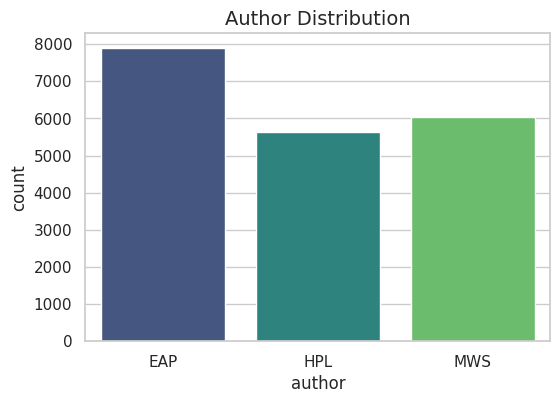

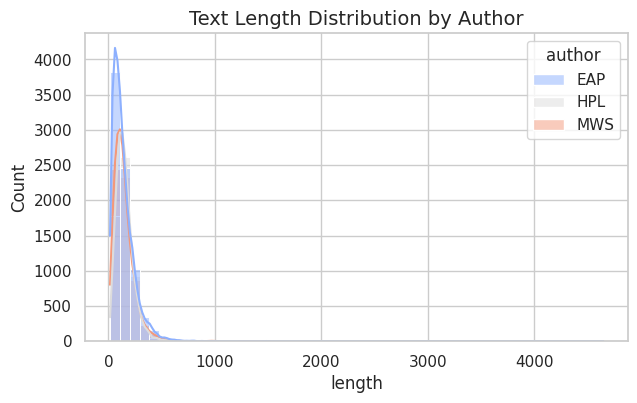


STYLOMETRY MODEL PERFORMANCE
Accuracy: 0.3324821246169561

TF-IDF MODEL PERFORMANCE
Accuracy: 0.8105209397344229
              precision    recall  f1-score   support

         EAP       0.80      0.84      0.82      1570
         HPL       0.80      0.79      0.79      1071
         MWS       0.84      0.79      0.82      1275

    accuracy                           0.81      3916
   macro avg       0.81      0.81      0.81      3916
weighted avg       0.81      0.81      0.81      3916



/tmp/ipykernel_7910/3370807486.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette="magma")


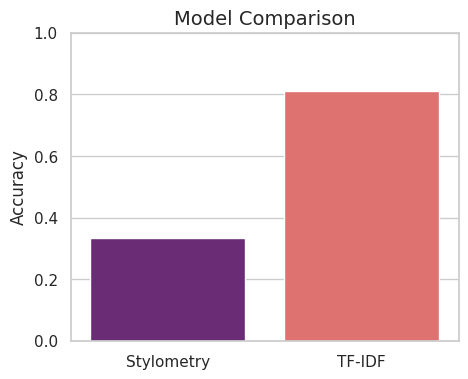

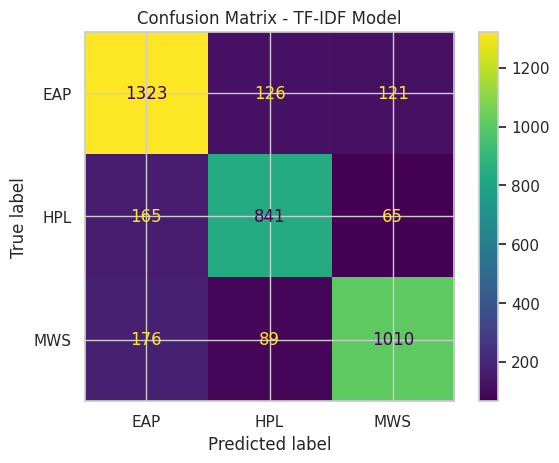

/tmp/ipykernel_7910/3370807486.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_words, palette="cubehelix")


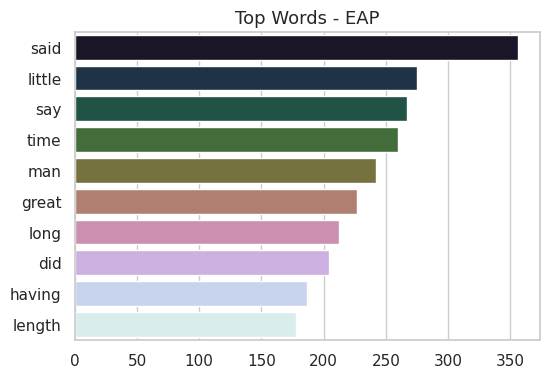

/tmp/ipykernel_7910/3370807486.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_words, palette="cubehelix")


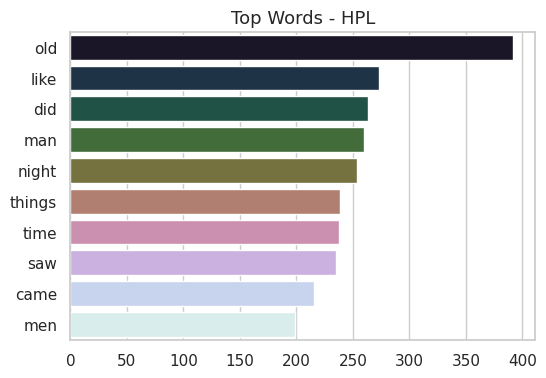

/tmp/ipykernel_7910/3370807486.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_words, palette="cubehelix")


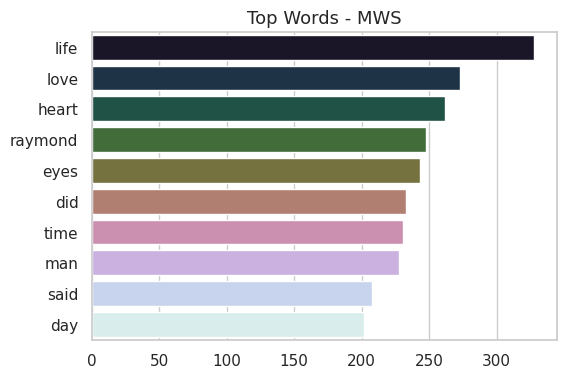


Sample Prediction
Text: This process, however, afforded me no means of ascertaining the dimensions of my dungeon; as I might
Predicted Author: EAP

--- AUTHENTICATION TEST ---
Enter text 1: Hiii
Enter text 2: BYEE
⚠️ Text too short for reliable prediction
Similarity: 0
❌ Different Author


In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression

sns.set(style="whitegrid")  # Better visuals

# =========================
# DATA LOADING
# =========================
df = pd.read_csv("train.csv")
df = df[["text", "author"]].dropna().reset_index(drop=True)

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print("Total samples:", len(df))
print(df["author"].value_counts())
print("="*50)

# =========================
# TEXT PREPROCESSING
# =========================
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["clean_text"] = df["text"].apply(preprocess)

# =========================
# STYLOMETRIC FEATURES
# =========================
def extract_features(text):
    words = text.split()

    avg_word_len = np.mean([len(w) for w in words]) if words else 0
    total_words = len(words)
    unique_words = len(set(words))
    vocab_richness = unique_words / total_words if total_words > 0 else 0

    char_count = len(text)
    stopwords = ["the","is","in","and","to","of","a"]
    stopword_count = sum([1 for w in words if w in stopwords])

    return [
        avg_word_len,
        total_words,
        vocab_richness,
        char_count,
        stopword_count
    ]

X_style = np.array(df["clean_text"].apply(extract_features).tolist())
y = df["author"]

scaler = StandardScaler()
X_style_scaled = scaler.fit_transform(X_style)

# =========================
# 🎨 VISUALIZATION 1: AUTHOR DISTRIBUTION (COLORFUL)
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x="author", data=df, palette="viridis")
plt.title("Author Distribution", fontsize=14)
plt.show()

# =========================
# 🎨 VISUALIZATION 2: TEXT LENGTH DISTRIBUTION (KDE)
# =========================
df["length"] = df["clean_text"].apply(len)

plt.figure(figsize=(7,4))
sns.histplot(data=df, x="length", hue="author", kde=True, bins=50, palette="coolwarm")
plt.title("Text Length Distribution by Author", fontsize=14)
plt.show()

# =========================
# STYLOMETRY MODEL
# =========================
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_style_scaled, y, test_size=0.2, random_state=42
)

author_profiles = {}
for author in df["author"].unique():
    author_profiles[author] = X_style_scaled[df["author"] == author].mean(axis=0)

def predict_author_style(text):
    text = preprocess(text)
    features = scaler.transform([extract_features(text)])

    sims = {}
    for author, profile in author_profiles.items():
        sim = cosine_similarity(features, profile.reshape(1, -1))[0][0]
        sims[author] = sim

    return max(sims, key=sims.get)

pred_style = [predict_author_style(df.iloc[i]["text"]) for i in range(len(X_test_s))]
acc_style = accuracy_score(y_test_s.values[:len(pred_style)], pred_style)

print("\nSTYLOMETRY MODEL PERFORMANCE")
print("Accuracy:", acc_style)

# =========================
# TF-IDF MODEL
# =========================
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df["clean_text"])

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_t, y_train_t)

y_pred = model.predict(X_test_t)
acc_tfidf = accuracy_score(y_test_t, y_pred)

print("\nTF-IDF MODEL PERFORMANCE")
print("Accuracy:", acc_tfidf)
print(classification_report(y_test_t, y_pred))

# =========================
# 🎨 VISUALIZATION 3: MODEL COMPARISON (GRADIENT COLORS)
# =========================
plt.figure(figsize=(5,4))
models = ["Stylometry", "TF-IDF"]
scores = [acc_style, acc_tfidf]

sns.barplot(x=models, y=scores, palette="magma")
plt.title("Model Comparison", fontsize=14)
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# =========================
# 🎨 VISUALIZATION 4: CONFUSION MATRIX (HEATMAP STYLE)
# =========================
cm = ConfusionMatrixDisplay.from_predictions(y_test_t, y_pred)
plt.title("Confusion Matrix - TF-IDF Model")
plt.show()

# =========================
# 🎨 VISUALIZATION 5: TOP WORDS PER AUTHOR
# =========================
count_vec = CountVectorizer(stop_words='english', max_features=1000)
X_counts = count_vec.fit_transform(df["clean_text"])
words = count_vec.get_feature_names_out()

for author in df["author"].unique():
    subset = df[df["author"] == author]
    X_sub = count_vec.transform(subset["clean_text"])

    word_counts = np.asarray(X_sub.sum(axis=0)).flatten()
    top_indices = word_counts.argsort()[-10:][::-1]

    top_words = [words[i] for i in top_indices]
    top_values = word_counts[top_indices]

    plt.figure(figsize=(6,4))
    sns.barplot(x=top_values, y=top_words, palette="cubehelix")
    plt.title(f"Top Words - {author}", fontsize=13)
    plt.show()

# =========================
# SAMPLE TEST
# =========================
sample = df.iloc[0]["text"]
print("\nSample Prediction")
print("Text:", sample[:100])
print("Predicted Author:", model.predict(vectorizer.transform([preprocess(sample)]))[0])

# =========================
# ✅ FIXED AUTHORSHIP VERIFICATION
# =========================
def verify_authorship(t1, t2):
    # Handle short text
    if len(t1.split()) < 3 or len(t2.split()) < 3:
        print("⚠️ Text too short for reliable prediction")
        return 0

    # Stylometric similarity
    f1 = scaler.transform([extract_features(preprocess(t1))])
    f2 = scaler.transform([extract_features(preprocess(t2))])
    sim_style = cosine_similarity(f1, f2)[0][0]

    # TF-IDF similarity
    v1 = vectorizer.transform([preprocess(t1)])
    v2 = vectorizer.transform([preprocess(t2)])
    sim_tfidf = cosine_similarity(v1, v2)[0][0]

    return 0.5 * sim_style + 0.5 * sim_tfidf

# =========================
# FINAL TEST
# =========================
print("\n--- AUTHENTICATION TEST ---")
t1 = input("Enter text 1: ")
t2 = input("Enter text 2: ")

sim = verify_authorship(t1, t2)

print("Similarity:", sim)

if sim > 0.8:
    print("✅ Same Author")
else:
    print("❌ Different Author")